In [12]:
import matplotlib.pyplot as plt
from draw_rna.ipynb_draw import draw_struct
import os
import re
from RNA import RNA
import matplotlib as mpl
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2   

import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


217


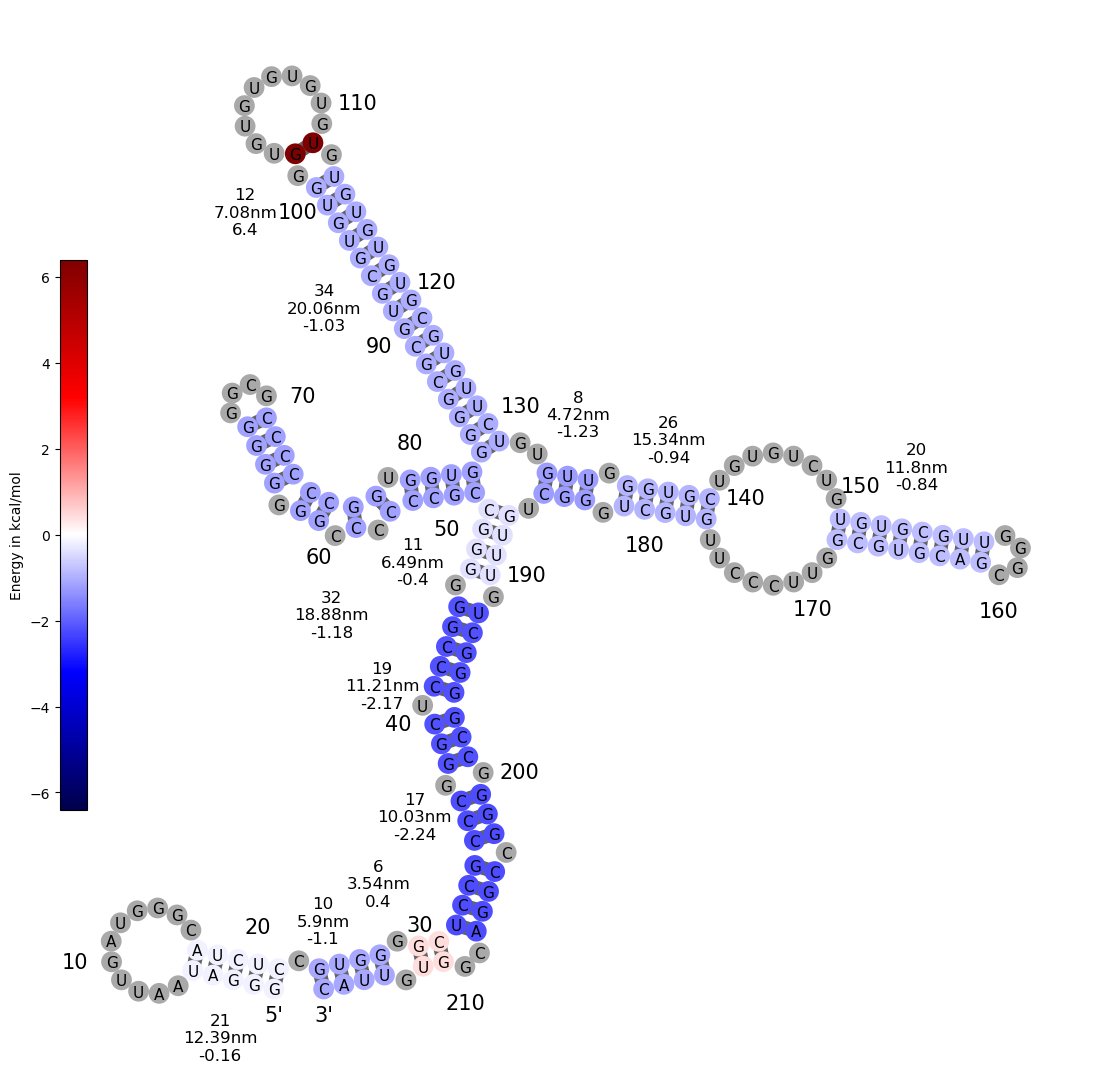

In [77]:
def get_ct(file_path):
    with open(file_path, 'r') as file:
        seq = file.readline().strip()
        print(len(seq))
        struct = file.readline().strip()
    return seq, struct

def get_energy_list(seq, struct):
    energy_list = {}
    external_values = 0
    with open('tmp.txt', 'w') as file:
        RNA.eval_structure_simple(seq, struct, 1, file)
    with open('tmp.txt', 'r') as file:
        for line in file.readlines():
            stripped = line.strip()
            val = int(stripped.split(':')[-1])
            digits = re.findall(r'\d+', stripped)
            digits = digits[:-1]
            digits = digits[0:2]
            if len(digits) == 0: external_values += val/100
            else:
                digit = int(digits[0])
                energy_list[digit-1] = val/100
                digit = int(digits[1])
                energy_list[digit-1] = val/100
    os.remove('tmp.txt')
    return energy_list

def ct_to_paired_list_count_all(file_path):
    seq, db = get_ct(file_path)
    i, j = 0, len(db)-1
    stack = []
    structures = []
    while i < len(db) and db[i] == '.':
        stack.append((i, db[i]))
        i+=1
    while i < len(db):
        while i < len(db) and (db[i] == '(' or  db[i] == '.'):
            stack.append((i, db[i]))
            i += 1
        tmp_struct = []
        cnt = 0
        while len(stack) and stack[-1][1] == '.': 
            stack.pop()
            cnt += 1
        while i < len(db) and len(stack) and \
                ((stack[-1][1] == '(' and db[i] == ')') or
                 (len(stack) >= 2 and stack[-1][1] == '.' and stack[-2][1] == '(' and db[i] == ')') or
                 (i+1 < len(db) and stack[-1][1] == '(' and db[i] == '.' and db[i+1] == ')')):
            match = stack.pop()
            if match[1] == '.': 
                match = stack.pop()
                cnt+=1
            if db[i] == '.': 
                i+=1
                cnt += 1
            tmp_struct.append((match[0], i))
            i+=1
        tmp_struct.append(cnt) # number of unpaired in center
        if tmp_struct:
            structures.append(tmp_struct)
    while len(stack):
        val = stack.pop()
        if val[1] != '.': 
            print("Error", val, i)
        if len(structures) > 0  and isinstance(structures[-1][0], int): 
            structures[-1][0] += 1
        else:
            structures.append([1])
    final_list = []
    for struc in structures:
        if len(struc) == 1: 
            final_list.append(struc[0]+len(stack)-1)
            continue
        unpaired_middle, start, end = struc[-1], struc[0], struc[-2]
        bases = (len(struc)-1)*2+struc[-1]
        length = round(bases*0.59,2)
        middle_bases = struc[int((len(struc)-1)/2)]
        position = int((start[0]-end[0])/2)+end[0]
        final_list.append((position, bases, length, middle_bases))
    str_list = []
    for item in final_list:
        if not isinstance(item, tuple): continue
        # str_list.append((item[0], f"{item[0]}\n{item[1]}\n{item[2]}"))
        str_list.append((item[0], f"{item[1]}\n{item[2]}nm"))
        # str_list.append((item[0], f"{item[2]}nm"))
    return final_list, str_list, seq, db, structures

def map_energy_to_color(energies, structures, seq, energies_individual=False):
    grey = (169,169,169)
    cmap = plt.get_cmap('seismic')
    energy_vals = np.array(list(energies.values()))
    max_energy = np.max(np.absolute(energy_vals))
    norm = mpl.colors.Normalize(vmin=-max_energy, vmax=max_energy)
    scalarMap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    colors = []
    for char in seq:
        colors.append(grey)
    if energies_individual:
        for segment in structures:
            for pairs in segment[:-1]:
                if pairs[0] in energies:
                    energy = energies[pairs[0]]
                else:
                    energy = energies[pairs[1]]
                colors[pairs[0]] = scalarMap.to_rgba(energy, bytes=True)[:-1]
                colors[pairs[1]] = scalarMap.to_rgba(energy, bytes=True)[:-1]
    else:
        for segment in structures:
            total_energy = 0
            for pairs in segment[:-1]:
                if pairs[0] in energies:
                    energy = energies[pairs[0]]
                else:
                    energy = energies[pairs[1]]
                total_energy += energy
            if total_energy:
                total_energy /= len(segment[:-1])
            for pairs in segment[:-1]:
                colors[pairs[0]] = scalarMap.to_rgba(total_energy, bytes=True)[:-1]
                colors[pairs[1]] = scalarMap.to_rgba(total_energy, bytes=True)[:-1]
    segment_energy = []
    for segment in structures:
        total_energy = 0
        for pairs in segment[:-1]:
            if pairs[0] in energies:
                energy = energies[pairs[0]]
            else:
                energy = energies[pairs[1]]
            total_energy += energy
        if total_energy:
            total_energy /= len(segment[:-1])
            segment_energy.append(total_energy)
        
    return colors, scalarMap, segment_energy
        

# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/dots/1.dt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_UNRESTRAINED_cleaned.txt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_RESTRAINED_cleaned.txt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/2.dt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/unfolding_steps/tmp.dt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/dots/1_tmp.dt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR-presentation/dots/1.dt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/1.dt'
def create_figure(file_path, large_mode=False, black_white=False, store_plt_svg=True, file_name=None, numbering=False, segment_lenghts=True, show_energies=False, energies_individual=False):
    final_list, final_str_list, seq, db, structures = ct_to_paired_list_count_all(file_path)
    energies = get_energy_list(seq, db)
    colors, scalar_map = None, None
    if show_energies:
        colors, scalar_map, segment_energy = map_energy_to_color(energies, structures, seq, energies_individual)
        for idx, (segment_str, seg_energy) in enumerate(zip(final_str_list, segment_energy)):
            final_str_list[idx] = (segment_str[0], segment_str[1]+f"\n{round(seg_energy,2)}") 
    if file_name is None:
        file_name=file_path.split('.')[0]
    if not segment_lenghts:
        final_str_list = None
    if numbering: numbering=list(range(1,len(seq)+1))
    else: numbering = None
    if black_white: seq = None
    else: seq = seq.upper()
    draw_struct(seq, db, c=colors, cmap='RdBu_r', scalar_map=scalar_map,  custom_text=final_str_list, store_plt_svg=store_plt_svg, filename=file_name, large_mode=large_mode, numbering=numbering)
    # draw_struct(seq, db, c=colors, cmap='RdBu_r', scalar_map=scalar_map,  custom_text=final_str_list, store_plt_svg=store_plt_svg, filename=file_name, large_mode=large_mode, numbering=numbering)


# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/dots/1_removed_linkers.dt'
# create_figure(file_path, show_energies=True, energies_individual=False, large_mode=True, file_name='grouped_energy.svg', numbering=False)
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_UNRESTRAINED_cleaned.txt'
# create_figure(file_path, show_energies=True, energies_individual=False, large_mode=True, file_name='grouped_energy.svg', numbering=False)
file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_RESTRAINED_cleaned.txt'
create_figure(file_path, show_energies=True, energies_individual=False, large_mode=False, file_name='grouped_energy.svg', numbering=True)
# create_figure(file_path, show_energies=True, energies_individual=True, large_mode=True, file_name='individual.svg')
# create_figure(file_path, show_energies=True, energies_individual=False)
# final_list, final_str_list, seq, db = ct_to_paired_list_count_all(file_path)

# draw_struct(seq.upper(), struct, cmap='RdBu_r',  custom_text=str_list, store_plt_svg=True, filename=file_path.split('.')[0], large_mode=True)
# draw_struct(seq.upper(), db, cmap='RdBu_r',  custom_text=final_str_list, store_plt_svg=True, filename=file_path.split('.')[0])


In [ ]:

# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/dots/1.dt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_UNRESTRAINED_cleaned.txt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_RESTRAINED_cleaned.txt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/dots/1_tmp.dt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR-presentation/dots/1.dt'
# file_path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/1.dt'
paths = [
        '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/dots/1.dt',
    '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_UNRESTRAINED_cleaned.txt',
    '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/ct2dot_LCMVL_RESTRAINED_cleaned.txt',
    '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/dots/1_tmp.dt',
    '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR-presentation/dots/1.dt',
    '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/1.dt',
]
for path in paths:
    final_list, final_str_list, seq, db = ct_to_paired_list_count_all(path)
    # print(path.split('.')[0]+'_large')
    draw_struct(seq.upper(), db, cmap='RdBu_r',  custom_text=final_str_list, store_plt_svg=True, filename=path.split('.')[0]+'_large', large_mode=True)
    draw_struct(seq.upper(), db, cmap='RdBu_r',  custom_text=final_str_list, store_plt_svg=True, filename=path.split('.')[0])

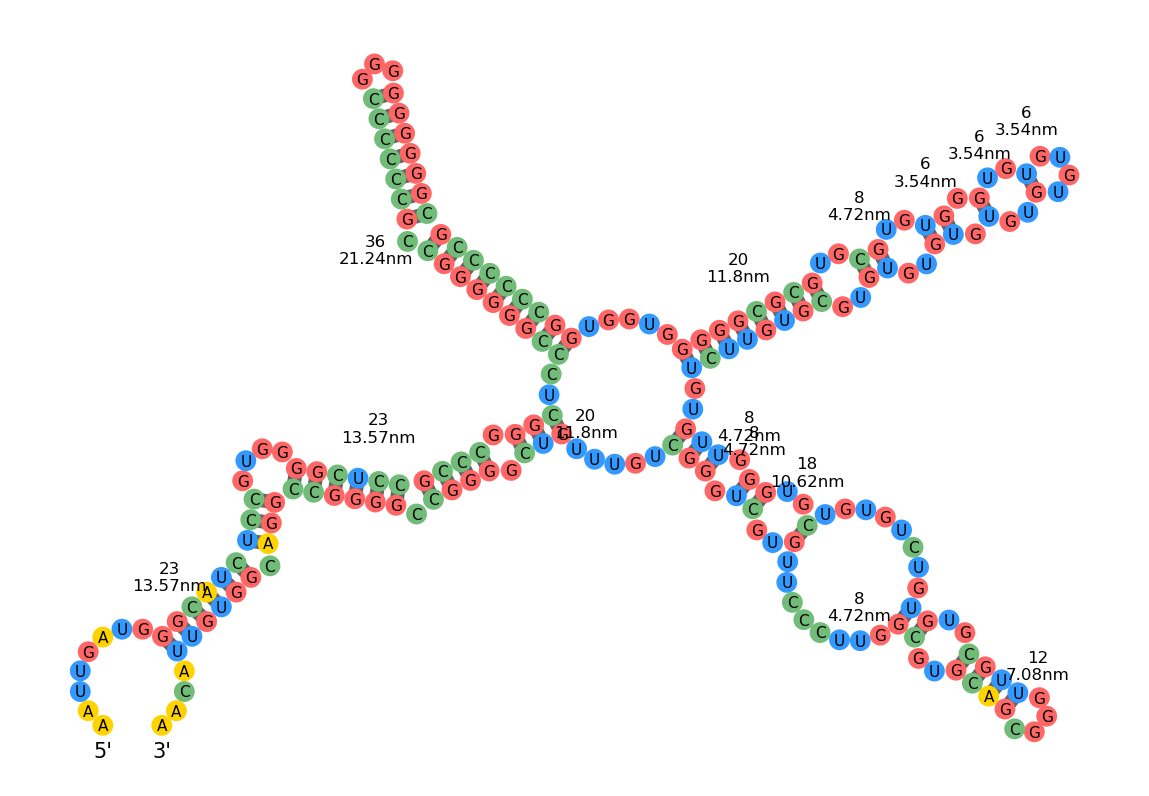

In [7]:
path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/unfolding_steps/folded.dt'
# path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/unfolding_steps/unfold1.dt'
# path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/unfolding_steps/unfold2a.dt'
# path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/unfolding_steps/unfold2b.dt'
# path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/unfolding_steps/unfold3.dt'
# path = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/LMVC-L-IGR/unfolding_steps/unfold4.dt'
final_list, final_str_list, seq, db = ct_to_paired_list_count_all(path)
# print(path.split('.')[0]+'_large')
# draw_struct(None, db, cmap='RdBu_r',  store_plt_svg=True, filename=path.split('.')[0]+'_large', large_mode=True)
# draw_struct(None, db, cmap='RdBu_r',  store_plt_svg=True, filename=path.split('.')[0]+'_large', large_mode=True)
draw_struct(seq.upper(), db, cmap='RdBu_r',  custom_text=final_str_list, store_plt_svg=True, filename=path.split('.')[0])